# Full Pipeline 04: Fine-Tune Multiple Policies (Including Attention DQN)

This notebook fine-tunes multiple RL policies on the merged full-pipeline state and exports refreshed validation/locked-test actions.

Included policies:
- DQN (SB3)
- A2C (SB3)
- PPO (SB3)
- AttentionDQN (custom agent in ml/agents/dqn_agent.py)

Inputs:
- output/full_pipeline/model_state_weekly_hmm_news.csv
- optional existing checkpoints under output/full_pipeline/ or output/models/

Outputs:
- output/full_pipeline/*_finetuned checkpoints
- output/full_pipeline/*_validation_actions_finetuned.csv
- output/full_pipeline/*_locked_test_actions_finetuned.csv

In [1]:
from pathlib import Path
import contextlib
import io
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from stable_baselines3 import A2C, DQN, PPO

REPO_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "full_pipeline").exists() and (candidate / "scripts").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repo root.")

PIPELINE_ROOT = REPO_ROOT / "full_pipeline"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

from evaluation import EvaluationConfig
from ml.agents import AttentionDQNAgent
from ml.hyperparameter_config import load_hyperparameter_config
from ml.training_utils import evaluate_episode, train_dqn_finrl
from _pipeline_utils import (
    OUTPUT_DIR,
    build_full_pipeline_artifacts,
    make_rl_env,
    prepare_rl_inputs,
    rollout_agent_on_split,
    save_action_frame,
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 220)

In [2]:
# Fine-tuning configuration loaded from shared YAML config
CONFIG_PATH = REPO_ROOT / "configs" / "rl_hyperparameters.yaml"
HP_CONFIG = load_hyperparameter_config(CONFIG_PATH, fast_mode=False)
CFG = HP_CONFIG.values

USE_CUDA = torch.cuda.is_available()
DEVICE = "cuda" if USE_CUDA else "cpu"

if USE_CUDA:
    # RTX 4080-oriented defaults: enable TF32 and cuDNN autotuning for throughput.
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

# Reduce noisy stderr logs when state auto-build triggers HMM grid search.
SUPPRESS_HMM_BUILD_STDERR = True

SEQ_LEN = int(CFG["general"]["sequence_length"])
EVAL_CONFIG = EvaluationConfig(
    transaction_cost=float(CFG["environment"]["transaction_cost"]),
    risk_penalty=float(CFG["environment"]["volatility_penalty"]),
    risk_window=int(CFG["environment"]["lookback_vol"]),
)

ENABLED_POLICIES = ["DQN", "A2C", "PPO", "ATTENTION_DQN"]

POLICY_CONFIGS = {
    "DQN": {
        "learning_rate": float(CFG["dqn"]["learning_rate"]),
        "exploration_fraction": float(CFG["dqn"]["exploration_fraction"]),
        "exploration_final_eps": float(CFG["dqn"]["exploration_final_eps"]),
        "target_update_interval": int(CFG["dqn"]["target_update_interval"]),
        "buffer_size": int(CFG["dqn"]["buffer_size"]),
        "batch_size": int(CFG["dqn"]["batch_size"]),
        "gamma": float(CFG["dqn"]["gamma"]),
        "eval_freq": int(CFG["dqn"]["eval_freq"]),
        "early_stopping_patience": int(CFG["dqn"]["early_stopping_patience"]),
        "warmup_timesteps": int(CFG["dqn"]["train_timesteps"]),
        "finetune_timesteps": int(CFG["dqn"]["train_timesteps"]),
    },
    "A2C": {
        "learning_rate": float(CFG["a2c"]["learning_rate"]),
        "gamma": float(CFG["a2c"]["gamma"]),
        "n_steps": int(CFG["a2c"]["n_steps"]),
        "ent_coef": float(CFG["a2c"]["ent_coef"]),
        "vf_coef": float(CFG["a2c"]["vf_coef"]),
        "warmup_timesteps": int(CFG["a2c"]["train_timesteps"]),
        "finetune_timesteps": int(CFG["a2c"]["train_timesteps"]),
    },
    "PPO": {
        "learning_rate": float(CFG["ppo"]["learning_rate"]),
        "n_steps": int(CFG["ppo"]["n_steps"]),
        "batch_size": int(CFG["ppo"]["batch_size"]),
        "n_epochs": int(CFG["ppo"]["n_epochs"]),
        "gamma": float(CFG["ppo"]["gamma"]),
        "gae_lambda": float(CFG["ppo"]["gae_lambda"]),
        "clip_range": float(CFG["ppo"]["clip_range"]),
        "ent_coef": float(CFG["ppo"]["ent_coef"]),
        "vf_coef": float(CFG["ppo"]["vf_coef"]),
        "warmup_timesteps": int(CFG["ppo"]["train_timesteps"]),
        "finetune_timesteps": int(CFG["ppo"]["train_timesteps"]),
    },
    "ATTENTION_DQN": {
        "learning_rate": float(CFG["dqn"]["learning_rate"]),
        "gamma": float(CFG["dqn"]["gamma"]),
        "buffer_capacity": int(CFG["dqn"]["buffer_size"]),
        "batch_size": int(CFG["dqn"]["batch_size"]),
        "target_update_freq": max(250, int(CFG["dqn"]["target_update_interval"] // 4)),
        "epsilon_start": float(CFG["dqn"]["exploration_initial_eps"]),
        "epsilon_end": float(CFG["dqn"]["exploration_final_eps"]),
        "epsilon_decay": 3000,
        "warmup_episodes": 6,
        "finetune_episodes": 10,
    },
}

CHECKPOINTS = {
    "DQN": {
        "base": OUTPUT_DIR / "dqn_hmm_news_base.zip",
        "finetuned": OUTPUT_DIR / "dqn_hmm_news_finetuned.zip",
        "fallback": REPO_ROOT / "output" / "models" / "dqn_finrl_agent.zip",
    },
    "A2C": {
        "base": OUTPUT_DIR / "a2c_hmm_news_base.zip",
        "finetuned": OUTPUT_DIR / "a2c_hmm_news_finetuned.zip",
        "fallback": REPO_ROOT / "output" / "models" / "a2c_finrl_agent.zip",
    },
    "PPO": {
        "base": OUTPUT_DIR / "ppo_hmm_news_base.zip",
        "finetuned": OUTPUT_DIR / "ppo_hmm_news_finetuned.zip",
        "fallback": REPO_ROOT / "output" / "models" / "ppo_finrl_agent.zip",
    },
    "ATTENTION_DQN": {
        "base": OUTPUT_DIR / "attention_dqn_hmm_news_base.pt",
        "finetuned": OUTPUT_DIR / "attention_dqn_hmm_news_finetuned.pt",
        "fallback": REPO_ROOT / "output" / "models" / "attention_dqn_agent.pt",
    },
}

print(f"Hyperparameter config: {CONFIG_PATH.relative_to(REPO_ROOT)}")
print(f"Resolved mode: {'fast' if HP_CONFIG.fast_mode else 'full'}")
print(f"Device: {DEVICE}")
if USE_CUDA:
    print("CUDA GPU:", torch.cuda.get_device_name(0))

print("Enabled policies:", ENABLED_POLICIES)
for policy_name in ENABLED_POLICIES:
    paths = CHECKPOINTS[policy_name]
    print(f"{policy_name} checkpoints:")
    print("  base:", paths["base"].relative_to(REPO_ROOT))
    print("  finetuned:", paths["finetuned"].relative_to(REPO_ROOT))
    print("  fallback:", paths["fallback"].relative_to(REPO_ROOT))

Hyperparameter config: configs/rl_hyperparameters.yaml
Resolved mode: full
Device: cuda
CUDA GPU: NVIDIA GeForce RTX 4080
Enabled policies: ['DQN', 'A2C', 'PPO', 'ATTENTION_DQN']
DQN checkpoints:
  base: output/full_pipeline/dqn_hmm_news_base.zip
  finetuned: output/full_pipeline/dqn_hmm_news_finetuned.zip
  fallback: output/models/dqn_finrl_agent.zip
A2C checkpoints:
  base: output/full_pipeline/a2c_hmm_news_base.zip
  finetuned: output/full_pipeline/a2c_hmm_news_finetuned.zip
  fallback: output/models/a2c_finrl_agent.zip
PPO checkpoints:
  base: output/full_pipeline/ppo_hmm_news_base.zip
  finetuned: output/full_pipeline/ppo_hmm_news_finetuned.zip
  fallback: output/models/ppo_finrl_agent.zip
ATTENTION_DQN checkpoints:
  base: output/full_pipeline/attention_dqn_hmm_news_base.pt
  finetuned: output/full_pipeline/attention_dqn_hmm_news_finetuned.pt
  fallback: output/models/attention_dqn_agent.pt


In [3]:
state_path = OUTPUT_DIR / "model_state_weekly_hmm_news.csv"
if not state_path.exists():
    print(f"Missing pipeline state at {state_path.relative_to(REPO_ROOT)}. Building full pipeline artifacts...")
    if SUPPRESS_HMM_BUILD_STDERR:
        stderr_buffer = io.StringIO()
        with contextlib.redirect_stderr(stderr_buffer):
            artifacts = build_full_pipeline_artifacts()
    else:
        artifacts = build_full_pipeline_artifacts()
    built_state = artifacts["artifact_paths"]["merged_state"]
    print(f"Built pipeline state: {Path(built_state).relative_to(REPO_ROOT)}")
else:
    print(f"Using existing pipeline state: {state_path.relative_to(REPO_ROOT)}")

prepared = prepare_rl_inputs(state_path=state_path)
frame = prepared["frame"]

train_env = make_rl_env(prepared, split="train", seq_len=SEQ_LEN, config=EVAL_CONFIG)
val_env = make_rl_env(prepared, split="validation", seq_len=SEQ_LEN, config=EVAL_CONFIG)
test_env = make_rl_env(prepared, split="locked_test", seq_len=SEQ_LEN, config=EVAL_CONFIG)

state_dim = int(train_env.observation_space.shape[-1])
action_dim = int(train_env.action_space.n)

display(prepared["dataset"].describe_splits())
display(prepared["dataset"].describe_feature_blocks())
print("Feature count:", len(prepared["feature_cols"]))
print("Posterior columns:", prepared["posterior_cols"])
print("State dim:", state_dim)
print("Action dim:", action_dim)

class AttentionAgentAdapter:
    """Adapter that exposes .predict for custom AttentionDQNAgent."""

    def __init__(self, core_agent):
        self.core_agent = core_agent

    def predict(self, obs, deterministic=True):
        action = self.core_agent.select_action(obs, training=not deterministic)
        return np.array([action], dtype=np.int64), None

def train_attention_dqn(agent, env, episodes, deterministic_eval=False):
    history = []
    for ep in range(int(episodes)):
        obs, _ = env.reset()
        done = False
        ep_reward = 0.0

        while not done:
            action = agent.select_action(obs, training=True)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = bool(terminated or truncated)
            agent.store_transition(obs, int(action), next_obs, float(reward), done)
            _ = agent.train_step()
            obs = next_obs
            ep_reward += float(reward)

        agent.episode_end()
        eval_reward = float(ep_reward)
        if deterministic_eval:
            eval_reward = float(evaluate_episode(AttentionAgentAdapter(agent), env, deterministic=True)["reward"])
        history.append({"episode": ep + 1, "reward": float(ep_reward), "eval_reward": eval_reward})

    return pd.DataFrame(history)

Using existing pipeline state: output/full_pipeline/model_state_weekly_hmm_news.csv


,split,rows,start,end
0,warmup,14,2014-03-28,2014-06-27
1,train,339,2014-07-04,2020-12-25
2,validation,105,2021-01-01,2022-12-30
3,locked_test,167,2023-01-06,2026-03-13


,block,n_columns,example_columns
0,price,35,"spy_ret_1d, spy_ret_5d, spy_ret_20d, spy_vol_5..."
1,macro,31,"bamlh0a0hym2_level, bamlh0a0hym2_chg_5d, cfnai..."
2,regime,4,"regime_filtered, regime_viterbi, filtered_prob..."
3,text,5,"news_finbert_compound_spy, news_finbert_compou..."


Feature count: 71
Posterior columns: ['filtered_prob_regime_0', 'filtered_prob_regime_1']
State dim: 77
Action dim: 7


## Load Existing Policies or Bootstrap Base Models

If a policy checkpoint is not found, the notebook trains a lightweight warmup model and saves it under output/full_pipeline.

In [4]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

models = {}
bootstrap_notes = []

def _try_load_sb3_model(algorithm_cls, candidate_paths, env, device):
    load_errors = []
    for ckpt_path in candidate_paths:
        if not ckpt_path.exists() or ckpt_path.suffix != ".zip":
            continue
        try:
            model = algorithm_cls.load(ckpt_path, env=env, device=device)
            return model, ckpt_path, load_errors
        except ValueError as exc:
            # Most common here: observation/action space mismatch after feature changes.
            load_errors.append(f"{ckpt_path.name}: {exc}")
    return None, None, load_errors

for policy_name in ENABLED_POLICIES:
    paths = CHECKPOINTS[policy_name]
    params = POLICY_CONFIGS[policy_name]
    candidate_paths = [paths["finetuned"], paths["base"], paths["fallback"]]

    if policy_name == "DQN":
        loaded_model, loaded_ckpt, load_errors = _try_load_sb3_model(
            DQN, candidate_paths, train_env, DEVICE
        )
        if loaded_model is not None:
            models[policy_name] = loaded_model
            bootstrap_notes.append({"policy": policy_name, "status": f"loaded {loaded_ckpt.name}"})
        else:
            if load_errors:
                print("Skipping incompatible DQN checkpoint(s):")
                for err in load_errors:
                    print("  -", err)
            warmup = train_dqn_finrl(
                train_env=train_env,
                val_env=val_env,
                total_timesteps=int(params["warmup_timesteps"]),
                eval_freq=int(params["eval_freq"]),
                early_stopping_patience=int(params["early_stopping_patience"]),
                learning_rate=float(params["learning_rate"]),
                exploration_fraction=float(params["exploration_fraction"]),
                exploration_final_eps=float(params["exploration_final_eps"]),
                target_update_interval=int(params["target_update_interval"]),
                buffer_size=int(params["buffer_size"]),
                batch_size=int(params["batch_size"]),
                device=DEVICE,
                verbose=1,
            )
            models[policy_name] = warmup["agent"]
            models[policy_name].save(paths["base"])
            bootstrap_notes.append({"policy": policy_name, "status": f"bootstrapped -> {paths['base'].name}"})

    elif policy_name == "A2C":
        loaded_model, loaded_ckpt, load_errors = _try_load_sb3_model(
            A2C, candidate_paths, train_env, DEVICE
        )
        if loaded_model is not None:
            models[policy_name] = loaded_model
            bootstrap_notes.append({"policy": policy_name, "status": f"loaded {loaded_ckpt.name}"})
        else:
            if load_errors:
                print("Skipping incompatible A2C checkpoint(s):")
                for err in load_errors:
                    print("  -", err)
            model = A2C(
                "MlpPolicy",
                train_env,
                learning_rate=float(params["learning_rate"]),
                gamma=float(params["gamma"]),
                n_steps=int(params["n_steps"]),
                ent_coef=float(params["ent_coef"]),
                vf_coef=float(params["vf_coef"]),
                verbose=1,
                device=DEVICE,
            )
            model.learn(total_timesteps=int(params["warmup_timesteps"]), progress_bar=True)
            model.save(paths["base"])
            models[policy_name] = model
            bootstrap_notes.append({"policy": policy_name, "status": f"bootstrapped -> {paths['base'].name}"})

    elif policy_name == "PPO":
        loaded_model, loaded_ckpt, load_errors = _try_load_sb3_model(
            PPO, candidate_paths, train_env, DEVICE
        )
        if loaded_model is not None:
            models[policy_name] = loaded_model
            bootstrap_notes.append({"policy": policy_name, "status": f"loaded {loaded_ckpt.name}"})
        else:
            if load_errors:
                print("Skipping incompatible PPO checkpoint(s):")
                for err in load_errors:
                    print("  -", err)
            model = PPO(
                "MlpPolicy",
                train_env,
                learning_rate=float(params["learning_rate"]),
                n_steps=int(params["n_steps"]),
                batch_size=int(params["batch_size"]),
                n_epochs=int(params["n_epochs"]),
                gamma=float(params["gamma"]),
                gae_lambda=float(params["gae_lambda"]),
                clip_range=float(params["clip_range"]),
                ent_coef=float(params["ent_coef"]),
                vf_coef=float(params["vf_coef"]),
                verbose=1,
                device=DEVICE,
            )
            model.learn(total_timesteps=int(params["warmup_timesteps"]), progress_bar=True)
            model.save(paths["base"])
            models[policy_name] = model
            bootstrap_notes.append({"policy": policy_name, "status": f"bootstrapped -> {paths['base'].name}"})

    elif policy_name == "ATTENTION_DQN":
        attn_agent = AttentionDQNAgent(
            state_dim=state_dim,
            action_dim=action_dim,
            seq_len=SEQ_LEN,
            learning_rate=float(params["learning_rate"]),
            gamma=float(params["gamma"]),
            epsilon_start=float(params["epsilon_start"]),
            epsilon_end=float(params["epsilon_end"]),
            epsilon_decay=int(params["epsilon_decay"]),
            buffer_capacity=int(params["buffer_capacity"]),
            batch_size=int(params["batch_size"]),
            target_update_freq=int(params["target_update_freq"]),
            use_dueling=True,
            device=DEVICE,
        )
        loaded_attention = False
        for ckpt_path in candidate_paths:
            if not ckpt_path.exists() or ckpt_path.suffix != ".pt":
                continue
            try:
                attn_agent.load_checkpoint(str(ckpt_path))
                bootstrap_notes.append({"policy": policy_name, "status": f"loaded {ckpt_path.name}"})
                loaded_attention = True
                break
            except Exception as exc:
                print(f"Skipping incompatible ATTENTION_DQN checkpoint {ckpt_path.name}: {exc}")

        if not loaded_attention:
            warmup_hist = train_attention_dqn(
                attn_agent,
                train_env,
                episodes=int(params["warmup_episodes"]),
            )
            attn_agent.save_checkpoint(str(paths["base"]))
            bootstrap_notes.append({"policy": policy_name, "status": f"bootstrapped -> {paths['base'].name}"})
            display(warmup_hist.tail(3))

        models[policy_name] = attn_agent

bootstrap_df = pd.DataFrame(bootstrap_notes)
display(bootstrap_df)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Output()

Skipping incompatible A2C checkpoint(s):
  - a2c_finrl_agent.zip: Observation spaces do not match: Box(-inf, inf, (4, 74), float32) != Box(-inf, inf, (4, 77), float32)
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 339      |
|    ep_rew_mean        | 0.206    |
| time/                 |          |
|    fps                | 773      |
|    iterations         | 100      |
|    time_elapsed       | 33       |
|    total_timesteps    | 25600    |
| train/                |          |
|    entropy_loss       | -1.94    |
|    explained_variance | 0.136    |
|    learning_rate      | 0.0005   |
|    n_updates          | 99       |
|    policy_loss        | 0.00136  |
|    value_loss         | 0.00386  |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 339      |
|    ep_rew_mean        | 0.226    |
| time/                 |          |
|    fps                | 788      |
|    iterations         | 200      |
|    time_elapsed       | 64       |
|    total_timesteps    | 51200    |
| train/                |          |
|    entropy_loss       | -1.94    |
|    explained_variance | 0.61     |
|    learning_rate      | 0.0005   |
|    n_updates          | 199      |
|    policy_loss        | -0.127   |
|    value_loss         | 0.00779  |
------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 339         |
|    ep_rew_mean          | 5.26        |
| time/                   |             |
|    fps                  | 753         |
|    iterations           | 487         |
|    time_elapsed         | 1323        |
|    total_timesteps      | 997376      |
| train/                  |             |
|    approx_kl            | 0.008566468 |
|    clip_fraction        | 0.00854     |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.0171     |
|    explained_variance   | 1           |
|    learning_rate        | 0.0003      |
|    loss                 | 0.00691     |
|    n_updates            | 4860        |
|    policy_gradient_loss | -0.000587   |
|    value_loss           | 1.69e-05    |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 339          |
|    ep_rew_mean          | 5.26         |
| time/                   |              |
|    fps                  | 753          |
|    iterations           | 489          |
|    time_elapsed         | 1328         |
|    total_timesteps      | 1001472      |
| train/                  |              |
|    approx_kl            | 0.0041656974 |
|    clip_fraction        | 0.00806      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.0154      |
|    explained_variance   | 1            |
|    learning_rate        | 0.0003       |
|    loss                 | -0.00507     |
|    n_updates            | 4880         |
|    policy_gradient_loss | -0.00264     |
|    value_loss           | 1.51e-06     |
------------------------------------------


Checkpoint saved to /home/yuaylong/Market-Regime-Detection-for-RL-Allocation/output/full_pipeline/attention_dqn_hmm_news_base.pt


,episode,reward,eval_reward
3,4,0.439937,0.439937
4,5,-0.007537,-0.007537
5,6,0.484442,0.484442


,policy,status
0,DQN,loaded dqn_hmm_news_base.zip
1,A2C,bootstrapped -> a2c_hmm_news_base.zip
2,PPO,bootstrapped -> ppo_hmm_news_base.zip
3,ATTENTION_DQN,bootstrapped -> attention_dqn_hmm_news_base.pt


In [5]:
baseline_rows = []

for policy_name, model in models.items():
    eval_model = AttentionAgentAdapter(model) if policy_name == "ATTENTION_DQN" else model
    val_stats = evaluate_episode(eval_model, val_env, deterministic=True)
    test_stats = evaluate_episode(eval_model, test_env, deterministic=True)

    baseline_rows.append(
        {"phase": "before_finetune", "policy": policy_name, "split": "validation", **val_stats}
    )
    baseline_rows.append(
        {"phase": "before_finetune", "policy": policy_name, "split": "locked_test", **test_stats}
    )

baseline_table = pd.DataFrame(baseline_rows)[
    [
        "phase",
        "policy",
        "split",
        "reward",
        "length",
        "cumulative_return",
        "sharpe_ratio",
        "max_drawdown",
    ]
]
display(baseline_table.sort_values(["policy", "split"]).reset_index(drop=True))

,phase,policy,split,reward,length,cumulative_return,sharpe_ratio,max_drawdown
0,before_finetune,A2C,locked_test,0.377633,167,0.754838,1.267776,-0.144490
1,before_finetune,A2C,validation,-0.142055,105,-0.038622,-0.030048,-0.270989
2,before_finetune,ATTENTION_DQN,locked_test,0.380228,167,0.716371,1.253960,-0.102508
3,before_finetune,ATTENTION_DQN,validation,-0.014159,105,0.086805,0.324370,-0.237877
4,before_finetune,DQN,locked_test,0.406525,167,0.744617,1.297047,-0.119609
5,before_finetune,DQN,validation,-0.155224,105,-0.048829,-0.068973,-0.217568
6,before_finetune,PPO,locked_test,0.442160,167,0.827749,1.380339,-0.176848
7,before_finetune,PPO,validation,-0.133932,105,-0.048730,-0.048552,-0.264382


## Fine-Tune All Policies and Re-Evaluate

Each enabled policy is fine-tuned on the train split, then evaluated on validation and locked test.

Output()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 339      |
|    ep_rew_mean      | 5.05     |
|    exploration_rate | 0.316    |
| time/               |          |
|    episodes         | 356      |
|    fps              | 321      |
|    time_elapsed     | 3        |
|    total_timesteps  | 121017   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 2.48e-06 |
|    n_updates        | 120016   |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 339      |
|    ep_rew_mean      | 5        |
|    exploration_rate | 0.308    |
| time/               |          |
|    episodes         | 360      |
|    fps              | 310      |
|    time_elapsed     | 7        |
|    total_timesteps  | 122373   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 1.39e-06 |
|    n_updates        | 121372   |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 339      |
|    ep_rew_mean      | 4.94     |
|    exploration_rate | 0.3      |
| time/               |          |
|    episodes         | 364      |
|    fps              | 313      |
|    time_elapsed     | 11       |
|    total_timesteps  | 123729   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 4.66e-07 |
|    n_updates        | 122728   |
----------------------------------


...

,phase,policy,split,reward,length,cumulative_return,sharpe_ratio,max_drawdown
0,after_finetune,A2C,locked_test,0.296361,167,0.606247,1.178000,-0.110413
1,after_finetune,A2C,validation,-0.005946,105,0.092722,0.340985,-0.261443
2,after_finetune,ATTENTION_DQN,locked_test,0.121368,167,0.299061,0.670158,-0.201161
3,after_finetune,ATTENTION_DQN,validation,-0.078654,105,0.005812,0.108009,-0.292609
4,after_finetune,DQN,locked_test,0.259179,167,0.522990,1.012219,-0.135393
5,after_finetune,DQN,validation,0.012613,105,0.124321,0.431413,-0.141754
6,after_finetune,PPO,locked_test,0.349430,167,0.685055,1.204521,-0.167075
7,after_finetune,PPO,validation,-0.162412,105,-0.061817,-0.095334,-0.214515


,phase,policy,split,reward,length,cumulative_return,sharpe_ratio,max_drawdown
0,after_finetune,A2C,locked_test,0.296361,167,0.606247,1.178000,-0.110413
1,after_finetune,A2C,validation,-0.005946,105,0.092722,0.340985,-0.261443
2,before_finetune,A2C,locked_test,0.377633,167,0.754838,1.267776,-0.144490
3,before_finetune,A2C,validation,-0.142055,105,-0.038622,-0.030048,-0.270989
4,after_finetune,ATTENTION_DQN,locked_test,0.121368,167,0.299061,0.670158,-0.201161
5,after_finetune,ATTENTION_DQN,validation,-0.078654,105,0.005812,0.108009,-0.292609
6,before_finetune,ATTENTION_DQN,locked_test,0.380228,167,0.716371,1.253960,-0.102508
7,before_finetune,ATTENTION_DQN,validation,-0.014159,105,0.086805,0.324370,-0.237877
8,after_finetune,DQN,locked_test,0.259179,167,0.522990,1.012219,-0.135393
9,after_finetune,DQN,validation,0.012613,105,0.124321,0.431413,-0.141754


Best model by split (weighted score):


,split,policy,sharpe_ratio,cumulative_return,reward,max_drawdown,score
0,locked_test,PPO,1.204521,0.685055,0.349430,-0.167075,0.800039
1,validation,DQN,0.431413,0.124321,0.012613,-0.141754,0.224734


Best validation model: DQN
Best locked-test model: PPO


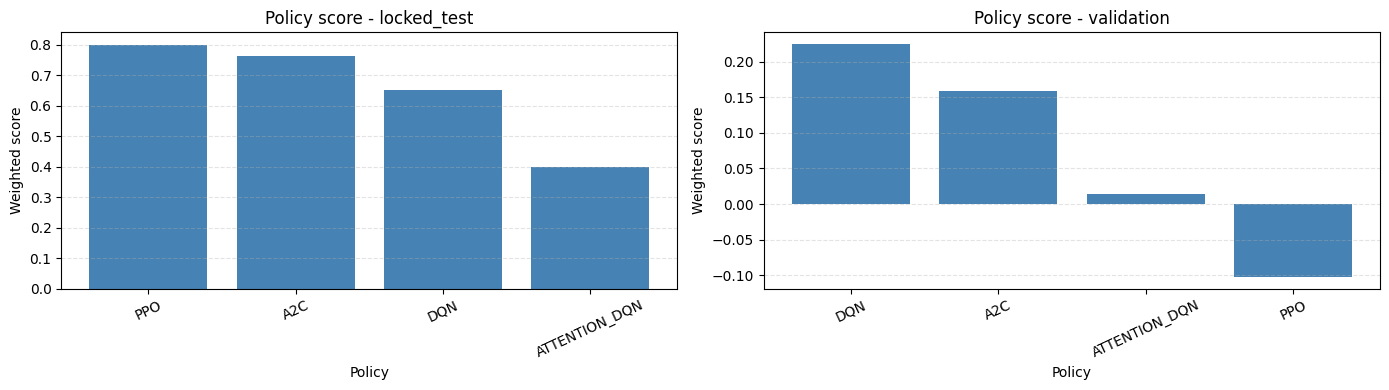

In [6]:
finetune_rows = []
finetune_notes = []

for policy_name, model in models.items():
    paths = CHECKPOINTS[policy_name]
    params = POLICY_CONFIGS[policy_name]

    if policy_name == "DQN":
        model.set_env(train_env)
        model.learn(
            total_timesteps=int(params["finetune_timesteps"]),
            reset_num_timesteps=False,
            progress_bar=True,
        )
        model.save(paths["finetuned"])
    elif policy_name == "A2C":
        model.set_env(train_env)
        model.learn(
            total_timesteps=int(params["finetune_timesteps"]),
            reset_num_timesteps=False,
            progress_bar=True,
        )
        model.save(paths["finetuned"])
    elif policy_name == "PPO":
        model.set_env(train_env)
        model.learn(
            total_timesteps=int(params["finetune_timesteps"]),
            reset_num_timesteps=False,
            progress_bar=True,
        )
        model.save(paths["finetuned"])
    elif policy_name == "ATTENTION_DQN":
        hist = train_attention_dqn(
            model,
            train_env,
            episodes=int(params["finetune_episodes"]),
        )
        model.save_checkpoint(str(paths["finetuned"]))
        display(hist.tail(3))

    finetune_notes.append(
        {"policy": policy_name, "saved": str(paths["finetuned"].relative_to(REPO_ROOT))}
    )

    eval_model = AttentionAgentAdapter(model) if policy_name == "ATTENTION_DQN" else model
    val_stats = evaluate_episode(eval_model, val_env, deterministic=True)
    test_stats = evaluate_episode(eval_model, test_env, deterministic=True)

    finetune_rows.append(
        {"phase": "after_finetune", "policy": policy_name, "split": "validation", **val_stats}
    )
    finetune_rows.append(
        {"phase": "after_finetune", "policy": policy_name, "split": "locked_test", **test_stats}
    )

finetuned_table = pd.DataFrame(finetune_rows)[
    [
        "phase",
        "policy",
        "split",
        "reward",
        "length",
        "cumulative_return",
        "sharpe_ratio",
        "max_drawdown",
    ]
]
comparison = pd.concat([baseline_table, finetuned_table], ignore_index=True)

display(pd.DataFrame(finetune_notes))
display(finetuned_table.sort_values(["policy", "split"]).reset_index(drop=True))
display(comparison.sort_values(["policy", "phase", "split"]).reset_index(drop=True))

# Model comparison summary: rank policies by split and an overall weighted score.
score_table = finetuned_table.groupby(["policy", "split"], as_index=False)[
    ["sharpe_ratio", "cumulative_return", "reward", "max_drawdown"]
].mean()
score_table["score"] = (
    0.45 * score_table["sharpe_ratio"]
    + 0.35 * score_table["cumulative_return"]
    + 0.10 * score_table["reward"]
    + 0.10 * score_table["max_drawdown"]
)

best_by_split = (
    score_table.sort_values(["split", "score"], ascending=[True, False])
    .groupby("split", as_index=False)
    .first()
    .sort_values("split")
    .reset_index(drop=True)
)

best_policy_validation = str(
    best_by_split.loc[best_by_split["split"] == "validation", "policy"].iloc[0]
)
best_policy_locked_test = str(
    best_by_split.loc[best_by_split["split"] == "locked_test", "policy"].iloc[0]
)

print("Best model by split (weighted score):")
display(best_by_split)

print(f"Best validation model: {best_policy_validation}")
print(f"Best locked-test model: {best_policy_locked_test}")

# Matplotlib view of weighted policy scores by split.
splits = list(score_table["split"].dropna().unique())
fig, axes = plt.subplots(1, len(splits), figsize=(7 * max(1, len(splits)), 4), squeeze=False)

for idx, split_name in enumerate(splits):
    ax = axes[0, idx]
    split_scores = score_table.loc[score_table["split"] == split_name].sort_values("score", ascending=False)
    ax.bar(split_scores["policy"], split_scores["score"], color="steelblue")
    ax.set_title(f"Policy score - {split_name}")
    ax.set_ylabel("Weighted score")
    ax.set_xlabel("Policy")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

fig.tight_layout()
plt.show()

In [7]:
validation_export_env = make_rl_env(prepared, split="validation", seq_len=SEQ_LEN, config=EVAL_CONFIG)
locked_test_export_env = make_rl_env(prepared, split="locked_test", seq_len=SEQ_LEN, config=EVAL_CONFIG)

export_rows = []
action_mix_tables = []

for policy_name, model in models.items():
    policy_agent = AttentionAgentAdapter(model) if policy_name == "ATTENTION_DQN" else model
    policy_key = policy_name.lower()

    val_actions = rollout_agent_on_split(policy_agent, validation_export_env, frame, "validation")
    test_actions = rollout_agent_on_split(policy_agent, locked_test_export_env, frame, "locked_test")

    val_path = save_action_frame(
        val_actions,
        OUTPUT_DIR / f"{policy_key}_validation_actions_finetuned.csv",
    )
    test_path = save_action_frame(
        test_actions,
        OUTPUT_DIR / f"{policy_key}_locked_test_actions_finetuned.csv",
    )

    export_rows.append(
        {
            "policy": policy_name,
            "validation_actions": str(val_path.relative_to(REPO_ROOT)),
            "locked_test_actions": str(test_path.relative_to(REPO_ROOT)),
        }
    )

    mix = pd.DataFrame(
        {
            "validation": val_actions["action_name"].value_counts(),
            "locked_test": test_actions["action_name"].value_counts(),
        }
    ).fillna(0).astype(int)
    mix["policy"] = policy_name
    action_mix_tables.append(mix.reset_index().rename(columns={"index": "action_name"}))

exports_df = pd.DataFrame(export_rows)
display(exports_df)

action_mix = pd.concat(action_mix_tables, ignore_index=True)
display(action_mix.sort_values(["policy", "action_name"]).reset_index(drop=True))

# Publish canonical aliases using the best validation policy from the comparison cell.
if "best_policy_validation" in globals():
    best_policy = best_policy_validation
else:
    fallback_rank = finetuned_table.loc[finetuned_table["split"] == "validation", ["policy", "sharpe_ratio"]].copy()
    fallback_rank = fallback_rank.sort_values("sharpe_ratio", ascending=False, na_position="last")
    best_policy = str(fallback_rank.iloc[0]["policy"])

best_key = best_policy.lower()
best_val_src = OUTPUT_DIR / f"{best_key}_validation_actions_finetuned.csv"
best_test_src = OUTPUT_DIR / f"{best_key}_locked_test_actions_finetuned.csv"
best_val_dst = OUTPUT_DIR / "rl_validation_actions_finetuned.csv"
best_test_dst = OUTPUT_DIR / "rl_locked_test_actions_finetuned.csv"
best_val_dst.write_text(best_val_src.read_text(encoding="utf-8"), encoding="utf-8")
best_test_dst.write_text(best_test_src.read_text(encoding="utf-8"), encoding="utf-8")

print(f"Best validation policy (for canonical exports): {best_policy}")
print("Canonical exports:")
print(" ", best_val_dst.relative_to(REPO_ROOT))
print(" ", best_test_dst.relative_to(REPO_ROOT))

,policy,validation_actions,locked_test_actions
0,DQN,output/full_pipeline/dqn_validation_actions_fi...,output/full_pipeline/dqn_locked_test_actions_f...
1,A2C,output/full_pipeline/a2c_validation_actions_fi...,output/full_pipeline/a2c_locked_test_actions_f...
2,PPO,output/full_pipeline/ppo_validation_actions_fi...,output/full_pipeline/ppo_locked_test_actions_f...
3,ATTENTION_DQN,output/full_pipeline/attention_dqn_validation_...,output/full_pipeline/attention_dqn_locked_test...


,action_name,validation,locked_test,policy
0,cash_only,5,58,A2C
1,gld_only,3,48,A2C
2,spy_80_tlt_20,4,0,A2C
3,spy_only,85,37,A2C
4,tlt_only,8,24,A2C
5,balanced_60_30_10,1,1,ATTENTION_DQN
6,cash_only,9,15,ATTENTION_DQN
7,defensive_20_60_20,1,0,ATTENTION_DQN
8,gld_only,7,52,ATTENTION_DQN
9,spy_80_tlt_20,2,0,ATTENTION_DQN


Best validation policy (for canonical exports): DQN
Canonical exports:
  output/full_pipeline/rl_validation_actions_finetuned.csv
  output/full_pipeline/rl_locked_test_actions_finetuned.csv
